# Motor Vehicle Insurance - Exploratory Data Analysis

## Project Overview
This notebook explores motor vehicle insurance data to understand customer behavior, policy characteristics, and claims patterns.

**Dataset**: Motor Vehicle Insurance Data from Mendeley  
**Rows**: ~105,000 policy records  
**Objective**: Discover insights about insurance premiums, claims, and customer demographics

## Step 1: Importing Libraries

- **pandas**: For data manipulation
- **matplotlib**: For creating visualizations
- **seaborn**: For beautiful statistical plots

In [39]:
 #Import pandas, matplotlib.pyplot, and seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set plot style and figure size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
#  Set pandas display options
pd.set_option('display.max_columns', None)

print("All libraries Imported succesfully")

All libraries Imported succesfully


## Step 2: Load the Data

The data is in CSV format with semicolon (;) as the separator.

In [40]:
# Load the CSV file with sep=';'
df = pd.read_csv('/Users/lavjeetbrar/Downloads/Motor vehicle insurance data.csv', sep = ';')
# Print the shape of the dataset

print(f"Dataset Loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset Loaded: 105,555 rows and 30 columns

First 5 rows:


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Date_lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,1,0,NaN,0,222.52,0.0,0,0,0.0,1,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,1,0,NaN,0,213.78,0.0,0,0,0.0,1,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,0,214.84,0.0,0,0,0.0,1,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,0,216.99,0.0,0,0,0.0,1,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,1,213.70,0.0,0,0,0.0,1,0,0,2004,80,599,7068.0,0,P,NaN,190


## Step 3: Understand the Data Structure

examining what columns are there and their data types.

In [41]:
# Use .info() to check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    105555 non-null  int64  
 1   Date_start_contract   105555 non-null  object 
 2   Date_last_renewal     105555 non-null  object 
 3   Date_next_renewal     105555 non-null  object 
 4   Date_birth            105555 non-null  object 
 5   Date_driving_licence  105555 non-null  object 
 6   Distribution_channel  105555 non-null  int64  
 7   Seniority             105555 non-null  int64  
 8   Policies_in_force     105555 non-null  int64  
 9   Max_policies          105555 non-null  int64  
 10  Max_products          105555 non-null  int64  
 11  Lapse                 105555 non-null  int64  
 12  Date_lapse            35147 non-null   object 
 13  Payment               105555 non-null  int64  
 14  Premium               105555 non-null  float64
 15  

In [42]:
#  Print all column names
print("Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}.{col}")

Column names:
1.ID
2.Date_start_contract
3.Date_last_renewal
4.Date_next_renewal
5.Date_birth
6.Date_driving_licence
7.Distribution_channel
8.Seniority
9.Policies_in_force
10.Max_policies
11.Max_products
12.Lapse
13.Date_lapse
14.Payment
15.Premium
16.Cost_claims_year
17.N_claims_year
18.N_claims_history
19.R_Claims_history
20.Type_risk
21.Area
22.Second_driver
23.Year_matriculation
24.Power
25.Cylinder_capacity
26.Value_vehicle
27.N_doors
28.Type_fuel
29.Length
30.Weight


## Step 4: Checking for Missing Values



In [43]:
# Calculate missing values count and percentage
missing = df.isnull().sum()
missing_pct = (missing/len(df))* 100
# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count' : missing,
    'Percentage' : missing_pct})

# Display columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending = False)
print("Columns with missing values:")
print(missing_summary)

Columns with missing values:
            Missing_Count  Percentage
Date_lapse          70408   66.702667
Length              10329    9.785420
Type_fuel            1764    1.671167


## Step 5: Summary Statistics

Looking at numerical summaries to understand the range and distribution of the data.

In [44]:
# Use .describe() to get summary statistics
df.describe()


,ID,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,95226.000000,105555.000000
mean,26271.286789,0.451310,6.696604,1.455649,1.837232,1.065842,0.221837,0.319180,315.892557,153.557305,0.394695,2.751760,0.425194,2.721804,0.273895,0.123708,2004.728038,92.682611,1617.759367,18413.657243,4.067898,4.252007,1191.262422
std,15388.309324,0.497626,6.263911,0.928427,1.155536,0.267807,0.464858,0.466161,140.927969,1477.112362,1.105018,3.881621,0.714883,0.614835,0.445958,0.329250,6.767037,37.012645,604.697382,9135.074235,1.511839,0.393220,458.081834
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.140000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1950.000000,0.000000,49.000000,270.460000,0.000000,1.978000,43.000000
25%,12925.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,241.610000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,2001.000000,75.000000,1390.000000,13127.210000,3.000000,3.999000,1043.000000
50%,26082.000000,0.000000,4.000000,1.000000,2.000000,1.000000,0.000000,0.000000,292.280000,0.000000,0.000000,1.000000,0.080000,3.000000,0.000000,0.000000,2005.000000,90.000000,1598.000000,17608.770000,5.000000,4.230000,1205.000000
75%,39754.000000,1.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,361.640000,0.000000,0.000000,4.000000,0.590000,3.000000,1.000000,0.000000,2008.000000,110.000000,1910.000000,22595.000000,5.000000,4.443000,1388.000000
max,53502.000000,1.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,260853.240000,25.000000,52.000000,26.070000,4.000000,1.000000,1.000000,2018.000000,580.000000,7480.000000,220675.800000,6.000000,8.218000,7300.000000


### Key Observations from Summary:
- **Premium**: Average premium is around €316
- **Cost_claims_year**: Most policies have no claims (mean close to 0)
- **Vehicle age**: Cars range from very old to brand new

## Step 6: Analyze Premium Distribution

**Question**: How are insurance premiums distributed?

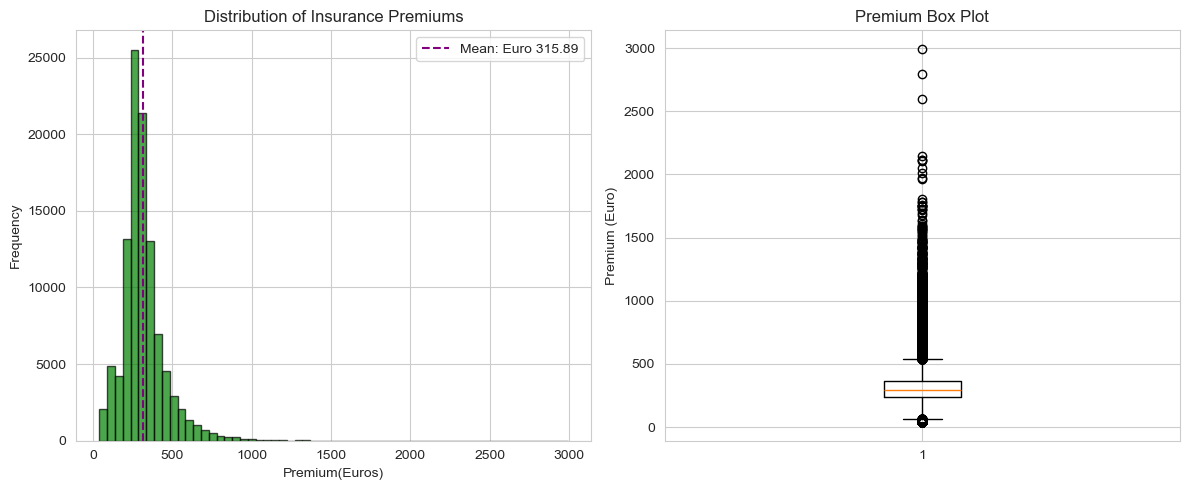

Average Premium:  315.89
Median Premium:  292.28
Min Premium:  40.14
Max Premium:  2993.34


In [45]:
#  Create a figure with 2 subplots
plt.figure(figsize = (12,5))
#  Plot histogram of Premium in first subplot
plt.subplot(1,2,1)
plt.hist(df['Premium'], bins = 60, color = 'green', alpha = 0.7, edgecolor = 'black')
plt.xlabel('Premium(Euros)')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Premiums')
plt.axvline(df['Premium'].mean(), color = 'purple', linestyle = '--', label = f'Mean: Euro{df['Premium'].mean(): .2f}')
plt.legend()

#  Plot boxplot of Premium in second subplot
plt.subplot(1,2,2)
plt.boxplot(df['Premium'], vert = True)
plt.ylabel('Premium (Euro)')
plt.title('Premium Box Plot')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Average Premium: {df['Premium'].mean(): .2f}")
print(f"Median Premium: {df['Premium'].median(): .2f}")
print(f"Min Premium: {df['Premium'].min(): .2f}")
print(f"Max Premium: {df['Premium'].max(): .2f}")


## Step 7: Claims Analysis

 How many policies have claims?

Policies with claims: 19,646 ( 18.6%)
Policies without claims; 85,909 ( 81.387902%)


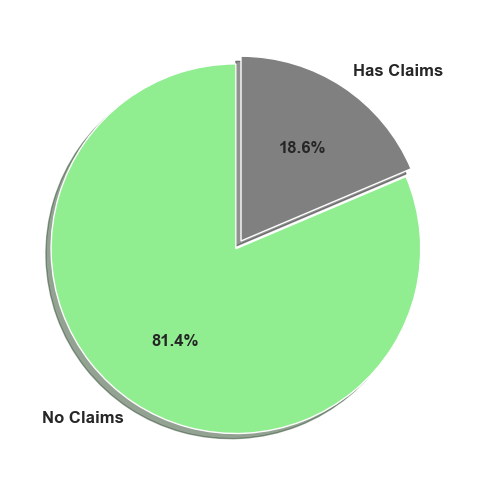

In [46]:
#  Count policies with claims (N_claims_year > 0)
claims_count = (df['N_claims_year'] > 0).sum()

#  Count policies without claims
no_claims_count = (df['N_claims_year'] == 0).sum()

#  Print counts and percentages
print(f"Policies with claims: {claims_count:,} ({claims_count / len(df) * 100 : .1f}%)")
print(f"Policies without claims; {no_claims_count:,} ({no_claims_count / len(df) * 100 : 1f}%)")

#  Create pie chart
plt.figure(figsize = (8,6))
labels = ['No Claims', 'Has Claims']
sizes = [no_claims_count, claims_count]
colors = ['lightgreen', 'grey']
explode = (0.05, 0)

plt.pie(sizes, explode = explode, labels = labels, colors = colors, autopct = '%1.1f%%', shadow = True, startangle = 90, textprops = {'fontsize' : 12, 'weight' : 'bold'})
plt.show()


## Step 8: Premium vs Claims Cost
 Is there a relationship between premium and claims cost?

Analyzing 19,646 policies that had claims...



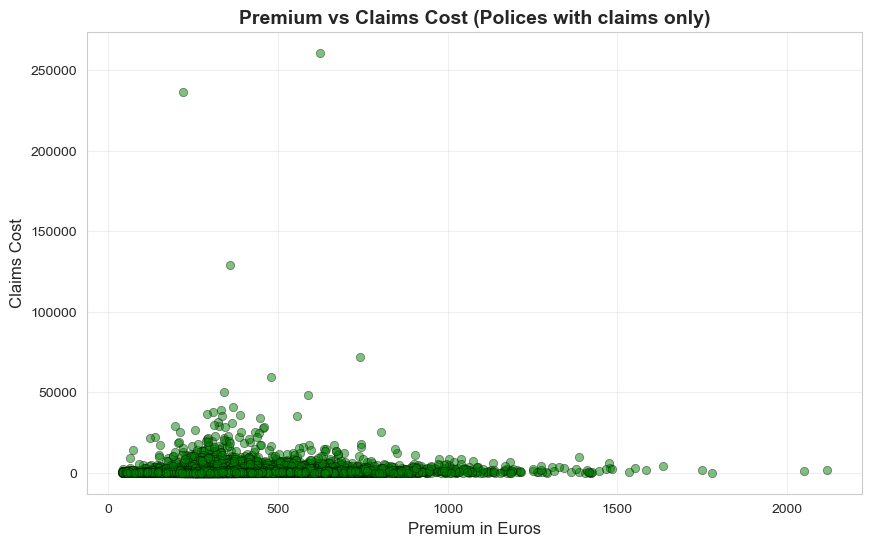

Correlation betweeen Premium and Claims cost:  0.067


In [47]:
#  Filter to policies with claims
df_with_claims = df[df['Cost_claims_year']>0]
print(f"Analyzing {len(df_with_claims):,} policies that had claims...\n")
#  Create scatter plot of Premium vs Cost_claims_year
plt.figure(figsize = (10, 6))
plt.scatter(df_with_claims['Premium'], df_with_claims['Cost_claims_year'],
            alpha = 0.5, color = 'green', edgecolors = 'black', linewidth = 0.5)
plt.xlabel('Premium in Euros', fontsize = 12)
plt.ylabel('Claims Cost' , fontsize = 12)
plt.title('Premium vs Claims Cost (Polices with claims only)', fontsize = 14, weight = 'bold')
plt.grid(True, alpha = 0.3)
plt.show()

# Calculate correlation
correlation = df_with_claims['Premium'].corr(df_with_claims['Cost_claims_year'])
print(f'Correlation betweeen Premium and Claims cost: {correlation: .3f}')

## Step 9: Vehicle Age Analysis

How old are the insured vehicles?

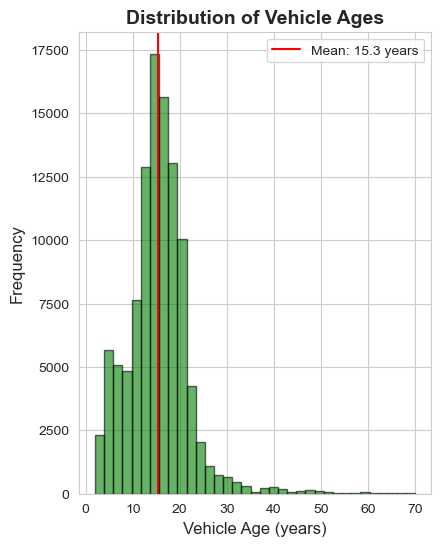

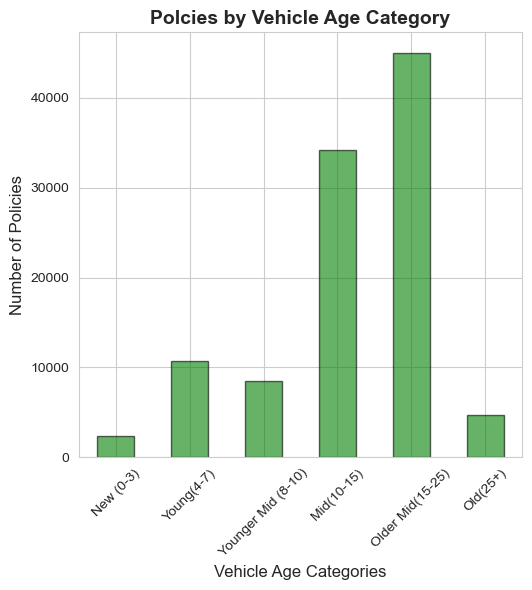

In [51]:
#  Calculate vehicle age (2020 - Year_matriculation)
df['vehicle_age'] = 2020 - df['Year_matriculation']
# Filter to valid ages (>= 0)
df_valid_age = df[df['vehicle_age'] >= 0] 
#  Plot histogram of vehicle ages
plt.subplot(1,2,1)
plt.hist(df_valid_age['vehicle_age'], bins = 35, color = 'green', alpha = 0.6, edgecolor = 'black')
plt.xlabel('Vehicle Age (years)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Vehicle Ages', fontsize = 14, weight = 'bold')
plt.axvline(df_valid_age['vehicle_age'].mean(), color = 'red', linestyle = 'solid', 
            label = f'Mean: {df_valid_age['vehicle_age'].mean():.1f} years')
plt.legend()
plt.show()

#  Create age categories and plot bar chart
plt.subplot(1,2,2)
age_bins = [0, 3, 7, 10, 15, 25, 100]
age_labels = ['New (0-3)', 'Young(4-7)', 'Younger Mid (8-10)', 'Mid(10-15)', 'Older Mid(15-25)', 'Old(25+)']
df_valid_age['Age_Category'] = pd.cut(df_valid_age['vehicle_age'], bins = age_bins, labels = age_labels)
age_counts = df_valid_age['Age_Category'].value_counts().sort_index()

age_counts.plot(kind = 'bar', color = 'green', alpha = 0.6, edgecolor = 'black')
plt.xlabel('Vehicle Age Categories', fontsize = 12)
plt.ylabel('Number of Policies', fontsize = 12) 
plt.title('Polcies by Vehicle Age Category', fontsize = 14, weight = 'bold')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()



## Step 10: Fuel Type Analysis

 What fuel types are most common?

Fuel Type Distribution
Type_fuel
D    64998
P    38793
Name: count, dtype: int64


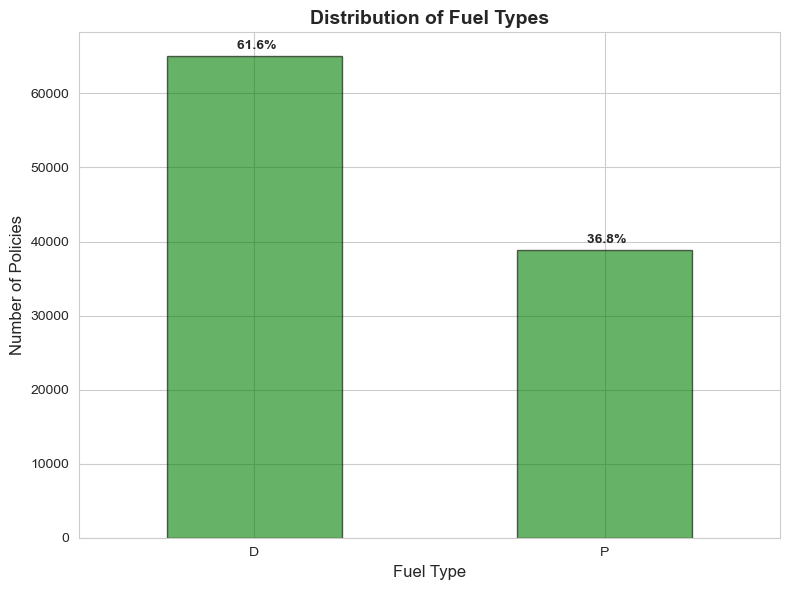

In [52]:
# Count fuel types using value_counts()
fuel_counts = df['Type_fuel'].value_counts()
print('Fuel Type Distribution')
print(fuel_counts)
# Create bar chart
plt.figure(figsize = (8,6))
fuel_counts.plot(kind = 'bar', color = 'green', alpha = 0.6, edgecolor = 'black')
plt.xlabel('Fuel Type', fontsize = 12)
plt.ylabel('Number of Policies', fontsize = 12)
plt.title('Distribution of Fuel Types', fontsize = 14, weight = 'bold')
plt.xticks(rotation = 0)
           
# Add percentage labels
for i, v in enumerate(fuel_counts):
    plt.text(i, v + 1000, f'{v/len(df) * 100 : .1f}%', ha = 'center', fontweight = 'bold') 
plt.tight_layout()
plt.show()


## Step 11: Premium by Vehicle Age
 Do older vehicles have different premiums?

Preimum Analysis by Vehicle Age
                    Average Premium  Median Premium  Policy Count
Age_Category                                                     
New (0-3)                398.772903         370.770          2332
Young(4-7)               401.451510         363.680         10737
Younger Mid (8-10)       346.876846         309.065          8520
Mid(10-15)               317.925856         297.785         34202
Older Mid(15-25)         297.201865         282.920         45039
Old(25+)                 188.137556         182.720          4725


/var/folders/jp/13jpq2c50tv3_q__84ppm63m0000gn/T/ipykernel_14404/859058676.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_by_age = df_valid_age.groupby('Age_Category')['Premium'].agg(['mean', 'median', 'count'])


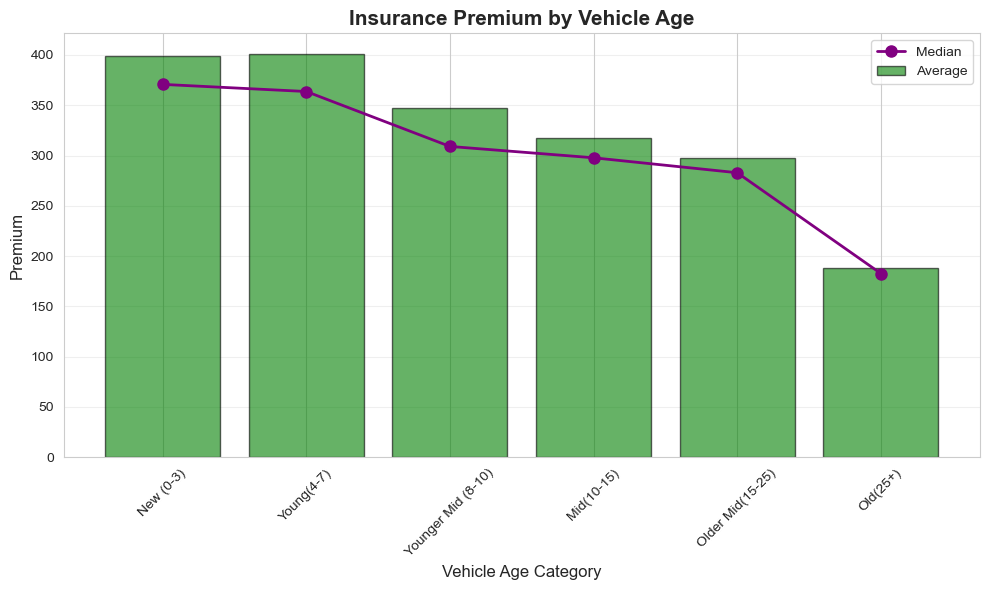

In [53]:
# Group by age category and calculate mean/median premium
premium_by_age = df_valid_age.groupby('Age_Category')['Premium'].agg(['mean', 'median', 'count'])
premium_by_age.columns = ['Average Premium', 'Median Premium', 'Policy Count']
print ('Preimum Analysis by Vehicle Age')
print(premium_by_age)
# Create bar chart with average and median
plt.figure(figsize = (10,6))
x = range(len(premium_by_age))
plt.bar(x, premium_by_age['Average Premium'], color = 'green', alpha = 0.6, edgecolor = 'black', label = 'Average')
plt.plot(x, premium_by_age['Median Premium'], color = 'purple', marker = 'o', linewidth = 2, markersize = 8, label = 'Median')
plt.xlabel('Vehicle Age Category', fontsize = 12)
plt.ylabel('Premium', fontsize  = 12)
plt.title('Insurance Premium by Vehicle Age', fontsize = 15, weight = 'bold')
plt.xticks(x, premium_by_age.index, rotation = 45)
plt.legend()
plt.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()



## Step 12: Claims Rate by Vehicle Age

**Question**: Do older vehicles have more claims?

Claims Analysis by Vehicle Age:
                    Total_Claims  Total_Policies  Claims_Rate
Age_Category                                                 
New (0-3)                    472            2332    20.240137
Young(4-7)                  3697           10737    34.432337
Younger Mid (8-10)          3121            8520    36.631455
Mid(10-15)                 13724           34202    40.126308
Older Mid(15-25)           19578           45039    43.468994
Old(25+)                    1070            4725    22.645503



/var/folders/jp/13jpq2c50tv3_q__84ppm63m0000gn/T/ipykernel_14404/1879993040.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  claims_by_age = df_valid_age.groupby('Age_Category').agg({


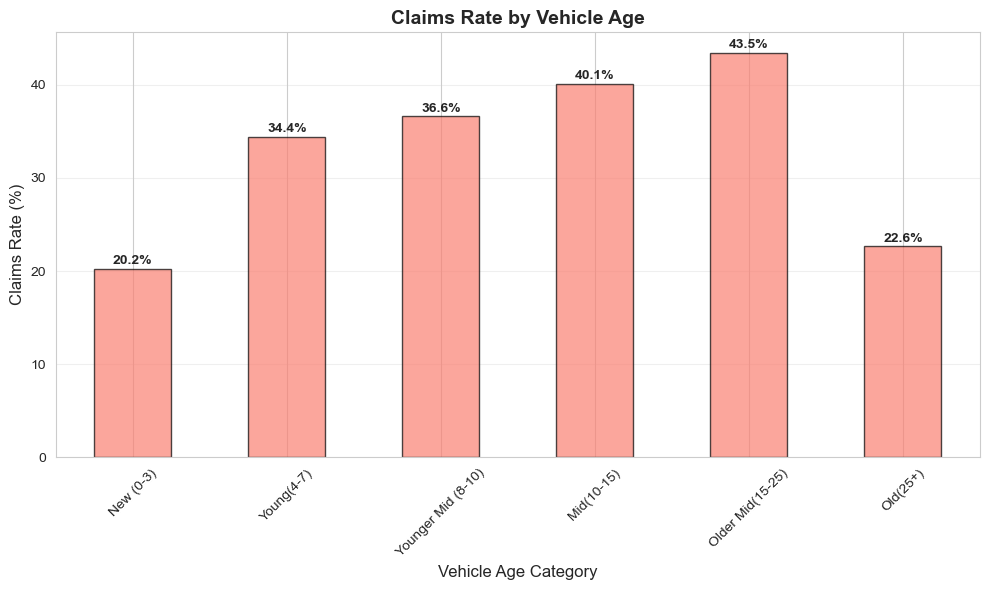

In [54]:
# TODO: Calculate total claims and policies by age category
claims_by_age = df_valid_age.groupby('Age_Category').agg({
    'N_claims_year': 'sum',
    'ID': 'count'
})
claims_by_age.columns = ['Total_Claims', 'Total_Policies']
claims_by_age['Claims_Rate'] = (claims_by_age['Total_Claims'] / claims_by_age['Total_Policies']) * 100

print("Claims Analysis by Vehicle Age:")
print(claims_by_age)
print()

#visualize 
plt.figure(figsize=(10, 6))
claims_by_age['Claims_Rate'].plot(kind='bar', color='salmon', alpha=0.7, edgecolor='black')
plt.xlabel('Vehicle Age Category', fontsize=12)
plt.ylabel('Claims Rate (%)', fontsize=12)
plt.title('Claims Rate by Vehicle Age', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(claims_by_age['Claims_Rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Step 13: Vehicle Power Analysis

 How does vehicle power affect premiums?

Premium by Vehicle Power:
                  Average Premium  Policy Count
Power_Category                                 
Low (0-75)             259.885972         31481
Medium (76-100)        318.988518         30987
High (101-150)         356.866158         38156
Very High (150+)       444.008785          3160



/var/folders/jp/13jpq2c50tv3_q__84ppm63m0000gn/T/ipykernel_14404/2446244976.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_by_power = df.groupby('Power_Category')['Premium'].agg(['mean', 'count'])


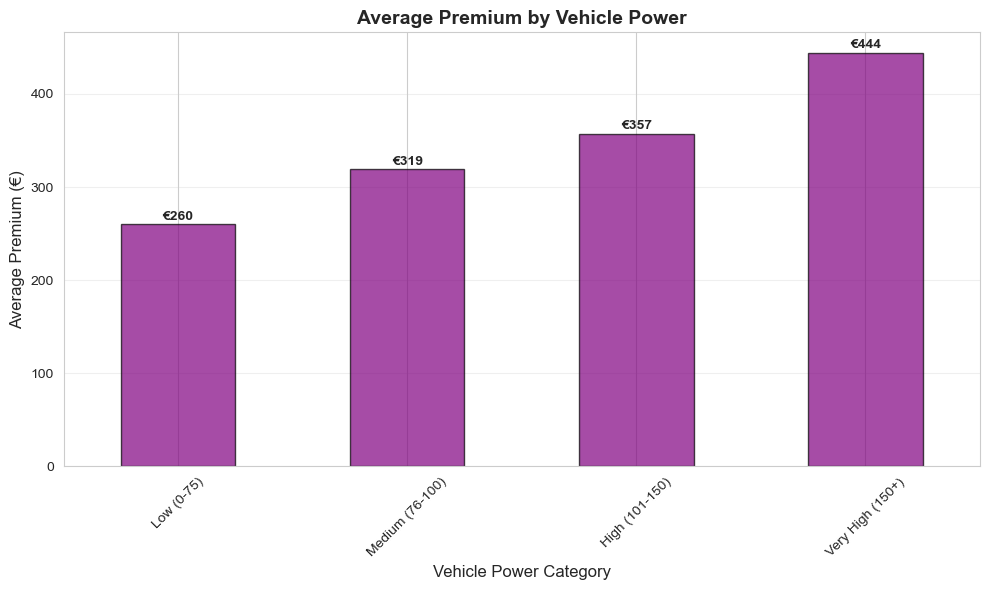

In [55]:
# Create power categories
power_bins = [0, 75, 100, 150, 500]
power_labels = ['Low (0-75)', 'Medium (76-100)', 'High (101-150)', 'Very High (150+)']
df['Power_Category'] = pd.cut(df['Power'], bins=power_bins, labels=power_labels)

# Calculate average premium by power
premium_by_power = df.groupby('Power_Category')['Premium'].agg(['mean', 'count'])
premium_by_power.columns = ['Average Premium', 'Policy Count']

print("Premium by Vehicle Power:")
print(premium_by_power)
print()

# Visualize
plt.figure(figsize=(10, 6))
premium_by_power['Average Premium'].plot(kind='bar', color='purple', alpha=0.7, edgecolor='black')
plt.xlabel('Vehicle Power Category', fontsize=12)
plt.ylabel('Average Premium (€)', fontsize=12)
plt.title('Average Premium by Vehicle Power', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(premium_by_power['Average Premium']):
    plt.text(i, v + 5, f'€{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 14: Key Findings Summary

Let's summarize what we discovered:

In [59]:
print("=" * 60)
print("KEY FINDINGS FROM EDA")
print("=" * 60)
print()

print("1. PREMIUM INSIGHTS:")
print(f"   • Average premium: €{df['Premium'].mean():.2f}")
print(f"   • Premium range: €{df['Premium'].min():.2f} to €{df['Premium'].max():.2f}")
print()

print("2. CLAIMS INSIGHTS:")
claims_pct = (df['N_claims_year'] > 0).sum() / len(df) * 100
print(f"   • Only {claims_pct:.1f}% of policies had claims")
print(f"   • Most policies are claim-free")
print()


print("3. PREMIUM DRIVERS:")
print(f"   • Higher power vehicles → Higher premiums")
print(f"   • Vehicle age affects premium")
print(f"   • Vehicle value correlates with premium")
print()

print("4. BUSINESS RECOMMENDATIONS:")
print(f"   • Focus on claim prevention (most policies claim-free)")
print(f"   • Consider vehicle age in pricing strategy")
print(f"   • High-power vehicles need appropriate risk pricing")
print()
print("=" * 60)

KEY FINDINGS FROM EDA

1. PREMIUM INSIGHTS:
   • Average premium: €315.89
   • Premium range: €40.14 to €2993.34

2. CLAIMS INSIGHTS:
   • Only 18.6% of policies had claims
   • Most policies are claim-free

3. PREMIUM DRIVERS:
   • Higher power vehicles → Higher premiums
   • Vehicle age affects premium
   • Vehicle value correlates with premium

4. BUSINESS RECOMMENDATIONS:
   • Focus on claim prevention (most policies claim-free)
   • Consider vehicle age in pricing strategy
   • High-power vehicles need appropriate risk pricing



## Conclusion

This exploratory data analysis revealed important patterns in motor vehicle insurance:

✅ **Data Quality**: The dataset is mostly complete with ~105K records  
✅ **Premium Distribution**: Most policies cluster around €200-250  
✅ **Claims Behavior**: Very few policies make claims (good for insurer)  
✅ **Vehicle Characteristics**: Age and power significantly influence premiums  
✅ **Risk Factors**: Older and higher-powered vehicles show different risk profiles  

**Next Steps**: 
- Build predictive models for claims probability
- Analyze customer churn patterns
- Deep dive into high-value policies